# 02 · Trùng timestamp

**Câu hỏi:** Trong một file `.plt` có nhiều bản ghi **cùng thời điểm**. Chúng là loại gì, và nên giữ bản nào?

**Quyết định** (đã áp dụng trong `_resolve_duplicate_groups` của `src/gps/data/processing.py`):

1. Trùng cả thời gian lẫn toạ độ: giữ 1 bản.
2. Trùng thời gian nhưng khác toạ độ: mỗi **ứng viên** được so với **điểm neo**, tức điểm *không trùng* gần nhất ngay trước và ngay sau nó trong cùng file. Ứng viên **hợp lệ** khi tốc độ tới cả hai điểm neo đều ≤ `impossible_speed_kmh` (1100 km/h, notebook 01).
3. Mỗi nhóm được xếp vào một trong bốn nhánh:

| Nhánh | Điều kiện | Xử lý |
|---|---|---|
| `no_valid` | 0 ứng viên hợp lệ | quarantine cả nhóm |
| `ambiguous` | ≥ 2 ứng viên hợp lệ cách nhau > 200 m (bán kính stay-point) | quarantine cả nhóm, không đoán |
| `single_valid` | đúng 1 ứng viên hợp lệ | giữ ứng viên đó |
| `tie_break` | ≥ 2 ứng viên hợp lệ, cách nhau ≤ 200 m | giữ theo quy ước: altitude hợp lệ trước, rồi thứ tự trong file |

Ứng viên bị loại vì tốc độ được ghi vào quarantine (`duplicate_rejected_candidate`).

**Cấu trúc:** Phần 1 khảo sát dữ liệu trùng. Phần 2 kiểm chứng quy tắc trên toàn bộ 182 user.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK = "02_duplicate_timestamps"
DATA_DIR = Path("../data/raw")
OUT_DIR = Path("outputs") / NOTEBOOK
FIG_DIR, TABLE_DIR, CACHE_DIR, MAP_DIR = (OUT_DIR / d for d in ("figures", "tables", "cache", "maps"))
for d in (FIG_DIR, TABLE_DIR, CACHE_DIR, MAP_DIR):
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(Path("../src").resolve()))
import json
from itertools import combinations

from gps.data.processing import (
    DEFAULT_THRESHOLDS, REASON_DUPLICATE, REASON_DUPLICATE_AMBIGUOUS, REASON_DUPLICATE_REJECTED,
    _haversine_vectorized, _resolve_duplicate_groups, filter_physical_bounds, load_plt_file,
    remove_speed_spikes,
)

T_IMPOSSIBLE = DEFAULT_THRESHOLDS.impossible_speed_kmh   # 1100 km/h (notebook 01)
STAY_RADIUS_M = 200                                      # stay-point radius (notebook 07)

## Phần 1 · Khảo sát dữ liệu trùng

Mỗi nhóm trùng (các bản ghi cùng `date_days`) được xếp vào một trong ba loại:
- **Case 1:** tất cả cùng toạ độ;
- **Case 2:** tất cả khác toạ độ;
- **Case 3:** lẫn lộn, có bản giống và có bản khác.

Nếu nhóm có altitude = −777 thì chỉ so `(lat, lon)`; nếu không thì so `(lat, lon, altitude)`. Kết quả được cache, vì lần chạy đầu phải quét toàn bộ dữ liệu thô.

In [2]:
BASE_DATE = pd.Timestamp("1899-12-30")
ALT_INVALID = -777
RAW_COLUMNS = ["lat", "lon", "reserved", "altitude", "date_days", "date_str", "time_str"]


def load_user(user_id: str) -> pd.DataFrame | None:
    """All .plt files of a user with source file and altitude validity."""
    files = sorted((DATA_DIR / user_id / "Trajectory").glob("*.plt"))
    if not files:
        return None
    df = pd.concat([pd.read_csv(f, skiprows=6, header=None, names=RAW_COLUMNS).assign(source_file=f.name)
                    for f in files], ignore_index=True)
    df["user_id"] = user_id
    df["is_alt_valid"] = df["altitude"] != ALT_INVALID
    return df


def classify_duplicate_case(group: pd.DataFrame) -> dict:
    """Case 1: identical coordinates; case 2: all different; case 3: mixed.
    Altitude is compared only when every altitude in the group is valid."""
    alt_valid = group["is_alt_valid"]
    cols = [group["lat"].round(6), group["lon"].round(6)]
    if alt_valid.all():
        cols.append(group["altitude"].round(10))
    unique_pairs = len(set(zip(*cols)))
    case = 1 if unique_pairs == 1 else (2 if unique_pairs == len(group) else 3)
    return {"case": case, "count": len(group), "unique_pairs": unique_pairs,
            "valid_alt": int(alt_valid.sum()), "invalid_alt": int((~alt_valid).sum()),
            "all_alt_valid": bool(alt_valid.all())}


def analyze_user_duplicates(df: pd.DataFrame) -> dict:
    """Per-user duplicate counts by case, plus up to 2 sample groups per case."""
    result = {"user_id": df["user_id"].iloc[0], "total_points": len(df), "has_duplicates": False,
              **{f"case{c}_{k}": 0 for c in (1, 2, 3) for k in ("ts", "pts")},
              "invalid_alt_ts": 0, "invalid_alt_pts": 0, "samples": []}
    dup = df[df.duplicated(subset=["date_days"], keep=False)]
    if dup.empty:
        return result
    result["has_duplicates"] = True
    per_case = {1: 0, 2: 0, 3: 0}
    for date_days, group in dup.groupby("date_days"):
        info = classify_duplicate_case(group)
        case = info["case"]
        result[f"case{case}_ts"] += 1
        result[f"case{case}_pts"] += info["count"]
        if not info["all_alt_valid"]:
            result["invalid_alt_ts"] += 1
            result["invalid_alt_pts"] += info["invalid_alt"]
        if per_case[case] < 2:
            per_case[case] += 1
            result["samples"].append({
                "date_days": float(date_days),
                "datetime": str(BASE_DATE + pd.Timedelta(days=date_days)),
                **{k: info[k] for k in ("case", "count", "unique_pairs", "valid_alt", "invalid_alt")},
                "records": group[["lat", "lon", "altitude", "is_alt_valid", "source_file"]].to_dict("records"),
            })
    return result


STATS_PATH = CACHE_DIR / "user_duplicate_stats.csv"
SAMPLES_PATH = CACHE_DIR / "duplicate_samples.json"
if STATS_PATH.exists() and SAMPLES_PATH.exists():
    user_stats = pd.read_csv(STATS_PATH, dtype={"user_id": str})
    user_results = json.loads(SAMPLES_PATH.read_text(encoding="utf-8"))
else:
    user_results = []
    for user_id in sorted(d.name for d in DATA_DIR.iterdir() if d.is_dir()):
        print(f"\ruser {user_id}", end="", flush=True)
        df = load_user(user_id)
        if df is not None:
            user_results.append(analyze_user_duplicates(df))
    print()
    user_stats = pd.DataFrame([{k: v for k, v in r.items() if k != "samples"} for r in user_results])
    user_stats.to_csv(STATS_PATH, index=False)
    SAMPLES_PATH.write_text(json.dumps(user_results, indent=2, ensure_ascii=False, default=str), encoding="utf-8")

user_stats.to_csv(TABLE_DIR / "user_duplicate_stats.csv", index=False)
total_points = int(user_stats["total_points"].sum())
case_pts = {c: int(user_stats[f"case{c}_pts"].sum()) for c in (1, 2, 3)}
case_ts = {c: int(user_stats[f"case{c}_ts"].sum()) for c in (1, 2, 3)}
dup_pts = sum(case_pts.values())
users_with_dup = int(user_stats["has_duplicates"].sum())

print(f"Users with duplicates : {users_with_dup}/{len(user_stats)} ({users_with_dup / len(user_stats):.1%})")
print(f"Duplicate points      : {dup_pts:,}/{total_points:,} ({dup_pts / total_points:.2%})")
for c, name in [(1, "same coordinates"), (2, "different coordinates"), (3, "mixed coordinates")]:
    print(f"  Case {c} ({name:21s}): {case_ts[c]:>8,} timestamps | {case_pts[c]:>8,} points")
print(f"Timestamps with an invalid altitude (-777): {int(user_stats['invalid_alt_ts'].sum()):,}")

Users with duplicates : 74/182 (40.7%)
Duplicate points      : 911,309/24,876,978 (3.66%)
  Case 1 (same coordinates     ):   54,530 timestamps |  139,027 points
  Case 2 (different coordinates):  120,897 timestamps |  587,849 points
  Case 3 (mixed coordinates    ):   36,982 timestamps |  184,433 points
Timestamps with an invalid altitude (-777): 0


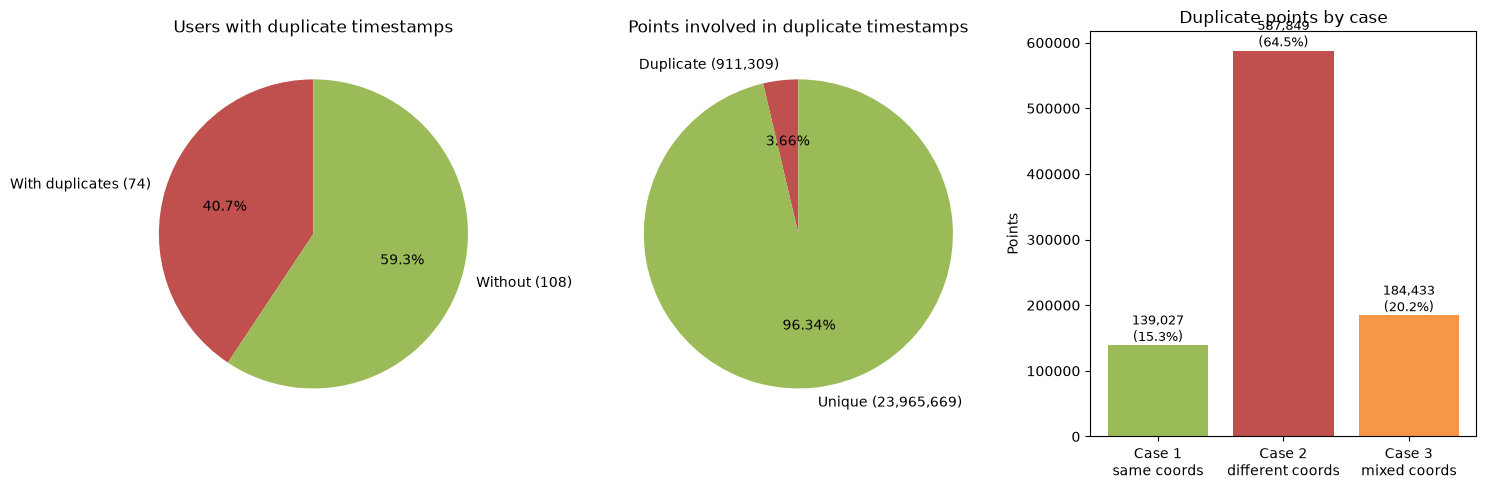

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].pie([users_with_dup, len(user_stats) - users_with_dup],
            labels=[f"With duplicates ({users_with_dup})", f"Without ({len(user_stats) - users_with_dup})"],
            colors=["#c0504d", "#9bbb59"], autopct="%1.1f%%", startangle=90)
axes[0].set_title("Users with duplicate timestamps")
axes[1].pie([dup_pts, total_points - dup_pts],
            labels=[f"Duplicate ({dup_pts:,})", f"Unique ({total_points - dup_pts:,})"],
            colors=["#c0504d", "#9bbb59"], autopct="%1.2f%%", startangle=90)
axes[1].set_title("Points involved in duplicate timestamps")
labels = ["Case 1\nsame coords", "Case 2\ndifferent coords", "Case 3\nmixed coords"]
bars = axes[2].bar(labels, [case_pts[c] for c in (1, 2, 3)], color=["#9bbb59", "#c0504d", "#f79646"])
for bar, c in zip(bars, (1, 2, 3), strict=True):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f"{case_pts[c]:,}\n({case_pts[c] / dup_pts:.1%})", ha="center", va="bottom", fontsize=9)
axes[2].set_title("Duplicate points by case")
axes[2].set_ylabel("Points")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig01_duplicate_overview.png", dpi=150, bbox_inches="tight")
plt.show()

### Khoảng cách giữa các bản ghi trong nhóm trùng (trên mẫu)

Với mỗi nhóm N bản ghi, tính khoảng cách của **tất cả** C(N, 2) cặp (ví dụ N = 3 thì có các cặp 1–2, 1–3, 2–3), rồi lấy min, median và max. **Max** là con số quyết định: nó cho biết nhóm có thực sự "cùng một vị trí" (chỉ là GPS rung) hay không.

Phần này chỉ tính trên **mẫu**: tối đa 2 nhóm cho mỗi case của mỗi user. Phân tích đầy đủ trên toàn bộ 157,865 nhóm nằm ở mục 2.3.

      count     mean       std  min  25%   50%   75%       max
case                                                          
2      91.0  15188.1  101381.8  0.2  5.0  15.9  63.0  688622.8
3      12.0      0.8       0.3  0.2  0.5   0.9   1.0       1.1


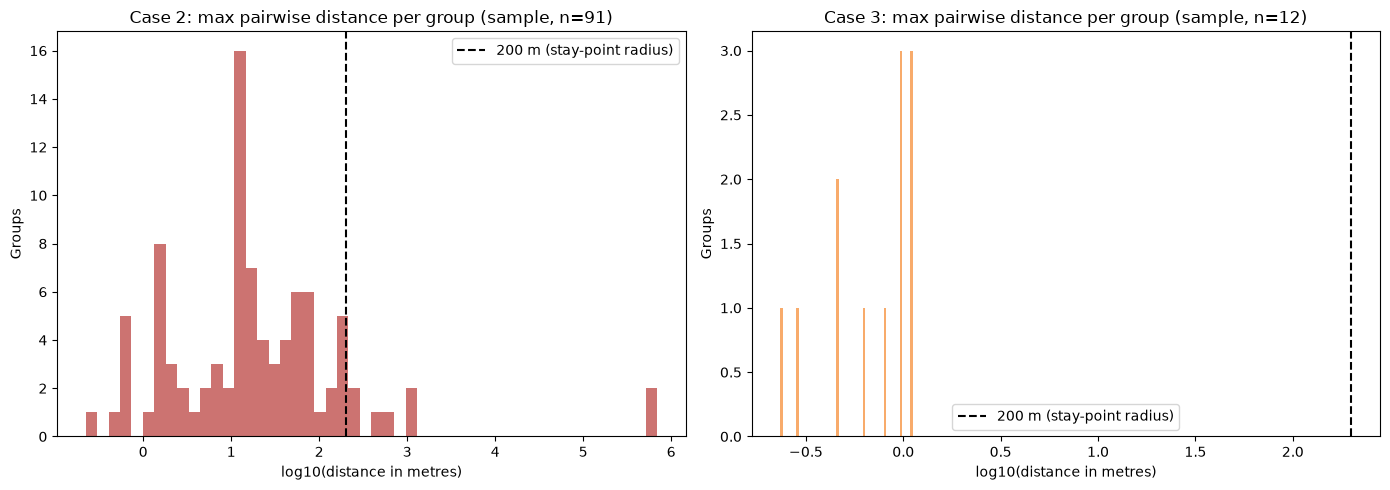

,user_id,datetime,case,count,min_dist_m,median_dist_m,max_dist_m
21,025,2009-05-15 01:43:35,2,2,688622.8,688622.8,688622.8
20,025,2009-05-15 01:00:00,2,2,686899.2,686899.2,686899.2
65,092,2008-08-12 09:00:36,2,3,56.7,1083.5,1140.0
64,092,2008-08-12 09:00:32,2,5,3.3,1021.8,1070.5
89,153,2009-04-19 03:47:50,2,2,573.9,573.9,573.9
4,009,2008-11-08 11:47:57,2,2,395.7,395.7,395.7
98,167,2008-05-21 11:13:37,2,2,282.9,282.9,282.9
12,013,2008-10-28 10:18:35,2,2,266.1,266.1,266.1
71,119,2008-09-24 03:59:34,2,2,200.0,200.0,200.0
25,030,2009-03-12 08:41:15,2,2,198.5,198.5,198.5


In [4]:
rows = []
for r in user_results:
    for s in r["samples"]:
        if s["case"] not in (2, 3):
            continue
        recs = s["records"]
        d = [float(_haversine_vectorized(a["lat"], a["lon"], b["lat"], b["lon"])) for a, b in combinations(recs, 2)]
        rows.append({"user_id": r["user_id"], "datetime": s["datetime"][:19], "case": s["case"], "count": s["count"],
                     "min_dist_m": min(d), "median_dist_m": float(np.median(d)), "max_dist_m": max(d)})
sample_dist = pd.DataFrame(rows)
sample_dist.to_csv(TABLE_DIR / "sample_group_distances.csv", index=False)
print(sample_dist.groupby("case")["max_dist_m"].describe().round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, case, color in [(axes[0], 2, "#c0504d"), (axes[1], 3, "#f79646")]:
    d = sample_dist.loc[sample_dist["case"] == case, "max_dist_m"]
    ax.hist(np.log10(d.clip(lower=0.01)), bins=50, color=color, alpha=0.8)
    ax.axvline(np.log10(STAY_RADIUS_M), color="black", linestyle="--", label=f"{STAY_RADIUS_M} m (stay-point radius)")
    ax.set_title(f"Case {case}: max pairwise distance per group (sample, n={len(d)})")
    ax.set_xlabel("log10(distance in metres)")
    ax.set_ylabel("Groups")
    ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig02_sample_group_distance_by_case.png", dpi=150, bbox_inches="tight")
plt.show()
sample_dist.sort_values("max_dist_m", ascending=False).head(10).round(1)

## Phần 2 · Kiểm chứng quy tắc trên toàn bộ dữ liệu

**Lập luận của quy tắc:** tại một thời điểm, người dùng chỉ ở một chỗ. Vị trí thật phải *đi tới được* từ vị trí thật ngay trước, và *đi tiếp được* tới vị trí thật ngay sau. Điểm neo là điểm không bị trùng, nên không bị nghi ngờ, và được dùng làm mốc.

Các câu hỏi cần kiểm chứng:
- **(a)** Trùng timestamp chỉ xảy ra trong một file?
- **(b)** Mỗi nhánh quyết định chiếm bao nhiêu? Các ứng viên cách nhau bao xa?
- **(c)** Ngưỡng 1100 km/h lỏng đến mức nào khi dùng ở đây? Điểm neo xa hoặc thiếu có làm sai quyết định không?
- **(d)** Ở những nhóm mà lựa chọn **thực sự** ảnh hưởng (> 200 m), dữ liệu có đủ để chọn không?
- **(e)** Kết quả có nhạy với con số 1100 không?
- **(f)** Có rủi ro điểm neo chính nó là điểm lỗi không?

**2.1 · Bảng ứng viên.** Hàm `candidate_table` lặp lại đúng logic của `src/`, nhưng giữ lại các chi tiết trung gian (điểm neo, khoảng thời gian, tốc độ). Quyết định của notebook được **đối chiếu 100%** với chính `src/`. Kết quả được cache.

In [5]:
def candidate_table(df: pd.DataFrame) -> pd.DataFrame | None:
    """One row per candidate of one file (after collapsing exact duplicates),
    mirroring _resolve_duplicate_groups. rank = priority within the group (0 = highest)."""
    t = DEFAULT_THRESHOLDS
    work = df.assign(_order=np.arange(len(df)), _alt_invalid=(df["altitude"] == t.altitude_invalid).to_numpy())
    work = (work.sort_values(["datetime", "_alt_invalid", "_order"], kind="stable")
                .drop_duplicates(["datetime", "lat", "lon"], keep="first").reset_index(drop=True))
    is_dup = work.duplicated("datetime", keep=False).to_numpy()
    if not is_dup.any():
        return None
    ts = work["datetime"].to_numpy("datetime64[ns]")
    lat, lon = work["lat"].to_numpy(float), work["lon"].to_numpy(float)
    anchor_idx, cand_idx = np.flatnonzero(~is_dup), np.flatnonzero(is_dup)
    pos = np.searchsorted(ts[anchor_idx], ts[cand_idx])
    n_anchor = len(anchor_idx)
    has_prev, has_next = pos > 0, pos < n_anchor
    last = max(n_anchor - 1, 0)
    prev_row = np.where(has_prev, anchor_idx[np.clip(pos - 1, 0, last)] if n_anchor else -1, -1)
    next_row = np.where(has_next, anchor_idx[np.clip(pos, 0, last)] if n_anchor else -1, -1)

    def leg(a, b, ok):
        dist, dt = np.full(len(cand_idx), np.nan), np.full(len(cand_idx), np.nan)
        dist[ok] = _haversine_vectorized(lat[a[ok]], lon[a[ok]], lat[b[ok]], lon[b[ok]])
        dt[ok] = np.abs(ts[b[ok]] - ts[a[ok]]) / np.timedelta64(1, "s")
        return dist, dt

    d_prev, dt_prev = leg(prev_row, cand_idx, has_prev)
    d_next, dt_next = leg(cand_idx, next_row, has_next)
    cands = pd.DataFrame({
        "row": cand_idx, "datetime": ts[cand_idx], "lat": lat[cand_idx], "lon": lon[cand_idx],
        "alt_invalid": work["_alt_invalid"].to_numpy()[cand_idx], "prev_row": prev_row, "next_row": next_row,
        "prev_time": np.where(has_prev, ts[np.maximum(prev_row, 0)], np.datetime64("NaT")),
        "next_time": np.where(has_next, ts[np.maximum(next_row, 0)], np.datetime64("NaT")),
        "dt_prev_s": dt_prev, "dt_next_s": dt_next, "d_prev_m": d_prev, "d_next_m": d_next,
        "v_in": d_prev / dt_prev * 3.6, "v_out": d_next / dt_next * 3.6,
    })
    cands["rank"] = cands.groupby("datetime").cumcount()
    return cands


def decide(cands: pd.DataFrame, threshold: float) -> pd.DataFrame:
    """Decision per group at `threshold` WITHOUT the ambiguity rule (the rule as it was
    before option A). kept_rank = rank of the kept candidate, -1 if quarantined."""
    key = ["user_id", "file", "datetime"]
    valid = ~(cands["v_in"] > threshold) & ~(cands["v_out"] > threshold)
    out = cands.assign(valid=valid).groupby(key, sort=False).agg(n_candidates=("rank", "size"), n_valid=("valid", "sum"))
    out["kept_rank"] = (cands.assign(r=np.where(valid, cands["rank"], np.inf)).groupby(key, sort=False)["r"].min()
                        .replace(np.inf, -1).astype(int))
    out["decision"] = np.select([out["n_valid"] == 0, out["n_valid"] == 1], ["no_valid", "single_valid"],
                                default="tie_break")
    return out


CANDS_PATH, SRC_DEC_PATH = CACHE_DIR / "candidates.parquet", CACHE_DIR / "src_decisions.parquet"
SUSPECT_PATH, SCOPE_PATH = CACHE_DIR / "suspect_points.parquet", CACHE_DIR / "scope.csv"
if CANDS_PATH.exists():
    cands, src_dec = pd.read_parquet(CANDS_PATH), pd.read_parquet(SRC_DEC_PATH)
    suspects, scope = pd.read_parquet(SUSPECT_PATH), pd.read_csv(SCOPE_PATH, dtype={"user_id": str})
else:
    cand_parts, dec_parts, sus_parts, scope_rows = [], [], [], []
    users = sorted(d.name for d in DATA_DIR.iterdir() if d.is_dir())
    for k, uid in enumerate(users, start=1):
        print(f"\r[{k}/{len(users)}] user {uid}", end="", flush=True)
        user_times = []
        for f in sorted((DATA_DIR / uid / "Trajectory").glob("*.plt")):
            raw = load_plt_file(f)
            user_times.append(pd.DataFrame({"datetime": raw["datetime"], "file": f.name}))
            df = filter_physical_bounds(raw, DEFAULT_THRESHOLDS)
            c = candidate_table(df) if len(df) else None
            if c is None:
                continue
            cand_parts.append(c.assign(user_id=uid, file=f.name))
            kept, _, dec = _resolve_duplicate_groups(df, DEFAULT_THRESHOLDS)
            dec_parts.append(dec.assign(user_id=uid, file=f.name))
            # points still suspect after cleaning: next to a > 1100 km/h step, or removed as spikes
            kept2, spikes = remove_speed_spikes(kept, DEFAULT_THRESHOLDS)
            ts = kept2["datetime"].to_numpy("datetime64[ns]")
            la, lo = kept2["lat"].to_numpy(), kept2["lon"].to_numpy()
            v = _haversine_vectorized(la[:-1], lo[:-1], la[1:], lo[1:]) / ((ts[1:] - ts[:-1]) / np.timedelta64(1, "s")) * 3.6
            bad = np.zeros(len(ts), bool)
            bad[1:] |= v > T_IMPOSSIBLE
            bad[:-1] |= v > T_IMPOSSIBLE
            sus_parts += [pd.DataFrame({"user_id": uid, "file": f.name, "datetime": ts[bad], "kind": "impossible_jump"}),
                          pd.DataFrame({"user_id": uid, "file": f.name, "kind": "spike_removed",
                                        "datetime": spikes["datetime"].to_numpy("datetime64[ns]")})]
        per_time = pd.concat(user_times, ignore_index=True).groupby("datetime")["file"].agg(["size", "nunique"])
        dup_times = per_time[per_time["size"] > 1]
        scope_rows.append({"user_id": uid, "n_dup_times": len(dup_times),
                           "n_dup_times_cross_file": int((dup_times["nunique"] > 1).sum())})
    print()
    cands, src_dec = pd.concat(cand_parts, ignore_index=True), pd.concat(dec_parts, ignore_index=True)
    suspects, scope = pd.concat(sus_parts, ignore_index=True), pd.DataFrame(scope_rows)
    cands.to_parquet(CANDS_PATH)
    src_dec.to_parquet(SRC_DEC_PATH)
    suspects.to_parquet(SUSPECT_PATH)
    scope.to_csv(SCOPE_PATH, index=False)

for frame, cols in [(cands, ["datetime", "prev_time", "next_time"]), (src_dec, ["datetime"]), (suspects, ["datetime"])]:
    for col in cols:
        frame[col] = frame[col].astype("datetime64[ns]")

groups = decide(cands, T_IMPOSSIBLE)

# Cross-check against src/. src/ additionally splits "ambiguous" out of tie_break (option A, 2.11);
# the cache may also hold the older label "quarantine" for no_valid.
chk = groups.reset_index().merge(src_dec, on=["user_id", "file", "datetime"], suffixes=("", "_src"))
assert len(chk) == len(groups) == len(src_dec), (len(chk), len(groups), len(src_dec))
src_labels = chk["decision_src"].replace({"quarantine": "no_valid", "ambiguous": "tie_break"})
assert (chk["decision"] == src_labels).all()
print(f"Candidates: {len(cands):,} | groups with differing coordinates: {len(groups):,} | "
      f"decisions identical to src/: {len(chk):,}/{len(groups):,}")

Candidates: 709,851 | groups with differing coordinates: 157,865 | decisions identical to src/: 157,865/157,865


### 2.2 · (a) Phạm vi: trùng chỉ xảy ra trong một file?
Nếu có trùng **giữa** hai file, thì xử lý từng file riêng sẽ bỏ sót, và phải xử lý theo cả user.

In [6]:
n_dup, n_cross = int(scope["n_dup_times"].sum()), int(scope["n_dup_times_cross_file"].sum())
print(f"Duplicated timestamps (all 182 users, incl. identical coordinates): {n_dup:,}")
print(f"  spanning >= 2 files: {n_cross:,} ({n_cross / n_dup:.2%})")

Duplicated timestamps (all 182 users, incl. identical coordinates): 212,409
  spanning >= 2 files: 0 (0.00%)


### 2.3 · (b) Các nhánh quyết định và khoảng cách giữa ứng viên
`max_dist_m` là khoảng cách lớn nhất giữa hai ứng viên bất kỳ trong nhóm, tính trên **toàn bộ** các nhóm. Mốc so sánh là 200 m (bán kính stay-point): nếu các ứng viên cách nhau dưới 200 m thì chọn cái nào cũng không làm đổi stay-point.

In [7]:
def max_pairwise_m(g: pd.DataFrame) -> float:
    la, lo = g["lat"].to_numpy(), g["lon"].to_numpy()
    i, j = np.array(list(combinations(range(len(la)), 2))).T
    return float(_haversine_vectorized(la[i], lo[i], la[j], lo[j]).max())

MAXD_PATH = CACHE_DIR / "group_max_dist.parquet"
if MAXD_PATH.exists():
    maxd = pd.read_parquet(MAXD_PATH)
else:
    maxd = cands.groupby(["user_id", "file", "datetime"], sort=False).apply(max_pairwise_m).rename("max_dist_m").to_frame()
    maxd.to_parquet(MAXD_PATH)
groups = groups.join(maxd)

branches = groups.groupby("decision").agg(
    groups=("n_candidates", "size"), median_candidates=("n_candidates", "median"),
    median_dist_m=("max_dist_m", "median"), p99_dist_m=("max_dist_m", lambda s: s.quantile(0.99)),
    max_dist_m=("max_dist_m", "max"), groups_over_200m=("max_dist_m", lambda s: int((s > STAY_RADIUS_M).sum())),
)
branches["share_pct"] = 100 * branches["groups"] / len(groups)
branches.to_csv(TABLE_DIR / "decision_branches.csv")
branches.round(1)

,groups,median_candidates,median_dist_m,p99_dist_m,max_dist_m,groups_over_200m,share_pct
decision,,,,,,,
no_valid,16,2.0,617318.3,844936.0,845183.0,16,0.0
single_valid,42,2.0,846243.1,852150.8,852277.7,42,0.0
tie_break,157807,5.0,1.4,14.0,104258.1,52,100.0


### 2.4 · (c) Ngưỡng 1100 km/h lỏng đến mức nào? Điểm neo xa hoặc thiếu thì sao?

**Hình dung quy tắc.** Trong `dt` giây, đi với 1100 km/h thì tới được xa nhất `1100 / 3.6 × dt ≈ 306 m × dt`. Mỗi điểm neo có một **vòng tròn** với bán kính đó (vòng quanh P dùng `dt` từ P tới ứng viên, vòng quanh N dùng `dt` từ ứng viên tới N). Ứng viên hợp lệ khi nằm **trong cả hai vòng**. Hình dưới đây:

1. **Hợp lệ và không hợp lệ:** C1 nằm trong phần giao của hai vòng; C2 nằm ngoài cả hai.
2. **Hợp lệ không có nghĩa là "nằm giữa" P và N về không gian.** Về thời gian thì ứng viên luôn nằm giữa P và N (theo định nghĩa điểm neo). Về không gian thì không bắt buộc, vì người đứng yên, rẽ góc hay quay đầu đều không đi theo đường thẳng. Bắt buộc "nằm giữa" sẽ loại nhầm điểm thật và cần thêm một ngưỡng không có bằng chứng.
3. **Khoảng cách giữa hai điểm neo được kiểm tra một cách ngầm định.** Nếu chính P và N đã là một bước nhảy không thể có, hai vòng không giao nhau (bất đẳng thức tam giác: `d(P,N) ≤ d(P,C) + d(C,N)`), nên không ứng viên nào hợp lệ và cả nhóm vào `no_valid`. Đây là lý do 16/16 nhóm `no_valid` có điểm neo lỗi (mục 2.9).

**Độ lỏng.** Để bị loại, ứng viên phải lệch ít nhất `306 m × dt` so với điểm neo **gần hơn**, và phải thoả cả hai phía nên phía gần hơn là phía ràng buộc chặt nhất. Quy tắc **không** giới hạn thời gian tới điểm neo, nên điểm neo càng xa thì quy tắc càng lỏng. Cell thứ hai bên dưới đo xem điểm neo xa hoặc thiếu có hay gặp không, và có rơi vào các nhóm mà lựa chọn có ảnh hưởng (ứng viên cách nhau > 200 m) không.

Điểm neo xa chỉ làm **nhiều ứng viên hợp lệ hơn**, dẫn tới `tie_break` (các ứng viên cách nhau ≤ 200 m, vô hại) hoặc `ambiguous` (quarantine). Nó không dẫn tới việc giữ nhầm một ứng viên sai, vì để loại được ứng viên đúng thì cần điểm neo **chặt**, không phải lỏng.

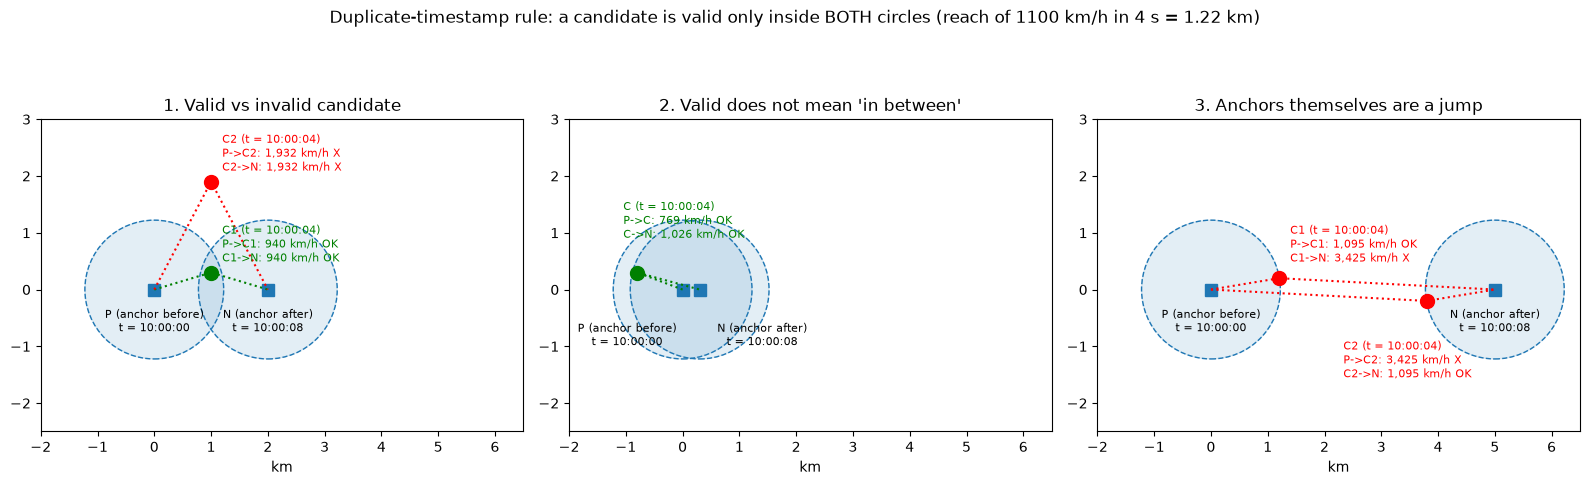

In [8]:
R_KM = T_IMPOSSIBLE / 3600 * 4   # reach in 4 s at 1100 km/h = 1.22 km
ILLUSTRATION = [
    ("1. Valid vs invalid candidate", (0, 0), (2, 0), [((1, 0.3), "C1", (8, 8)), ((1, 1.9), "C2", (8, 8))], ((0, -30), (0, -30))),
    ("2. Valid does not mean 'in between'", (0, 0), (0.3, 0), [((-0.8, 0.3), "C", (-10, 25))], ((-40, -40), (45, -40))),
    ("3. Anchors themselves are a jump", (0, 0), (5, 0), [((1.2, 0.2), "C1", (8, 12)), ((3.8, -0.2), "C2", (-60, -55))], ((0, -30), (0, -30))),
]
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
for ax, (title, P, N, cands_xy, offs) in zip(axes, ILLUSTRATION, strict=True):
    for (x, y), label, off in [(P, "P (anchor before)\nt = 10:00:00", offs[0]), (N, "N (anchor after)\nt = 10:00:08", offs[1])]:
        ax.add_patch(plt.Circle((x, y), R_KM, color="#1f77b4", alpha=0.12))
        ax.add_patch(plt.Circle((x, y), R_KM, fill=False, color="#1f77b4", ls="--"))
        ax.plot(x, y, "s", color="#1f77b4", ms=9)
        ax.annotate(label, (x, y), xytext=off, textcoords="offset points", ha="center", fontsize=8)
    for (x, y), name, off in cands_xy:
        v_in = np.hypot(x - P[0], y - P[1]) / 4 * 3600
        v_out = np.hypot(x - N[0], y - N[1]) / 4 * 3600
        color = "green" if max(v_in, v_out) <= T_IMPOSSIBLE else "red"
        ax.plot(x, y, "o", color=color, ms=10)
        ax.plot([P[0], x, N[0]], [P[1], y, N[1]], ":", color=color)
        ax.annotate(f"{name} (t = 10:00:04)\nP->{name}: {v_in:,.0f} km/h {'OK' if v_in <= T_IMPOSSIBLE else 'X'}\n"
                    f"{name}->N: {v_out:,.0f} km/h {'OK' if v_out <= T_IMPOSSIBLE else 'X'}",
                    (x, y), xytext=off, textcoords="offset points", fontsize=8, color=color)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(-2, 6.5)
    ax.set_ylim(-2.5, 3)
    ax.set_xlabel("km")
fig.suptitle(f"Duplicate-timestamp rule: a candidate is valid only inside BOTH circles "
             f"(reach of {T_IMPOSSIBLE:.0f} km/h in 4 s = {R_KM:.2f} km)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig03_anchor_rule_illustration.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
g_dt = cands.groupby(["user_id", "file", "datetime"], sort=False).agg(
    dt_prev_s=("dt_prev_s", "first"), dt_next_s=("dt_next_s", "first"))
g_dt["dt_min_s"] = g_dt[["dt_prev_s", "dt_next_s"]].min(axis=1)
g_dt["min_offset_to_reject_m"] = T_IMPOSSIBLE / 3.6 * g_dt["dt_min_s"]
groups = groups.join(g_dt)
print(groups[["dt_min_s", "min_offset_to_reject_m"]].describe(percentiles=[.5, .9, .99, .999]).round(1).to_string())
print(f"\nGroups without an anchor on EITHER side (nothing to check against): "
      f"{int((groups['dt_prev_s'].isna() & groups['dt_next_s'].isna()).sum())}")
print(f"Groups with an anchor on one side only (start/end of file): "
      f"{int((groups['dt_prev_s'].isna() ^ groups['dt_next_s'].isna()).sum())}")

far_anchor = pd.DataFrame([
    {"nearest_anchor_over_s": T, "groups": int((groups["dt_min_s"] > T).sum()),
     "groups_candidates_over_200m": int(((groups["dt_min_s"] > T) & (groups["max_dist_m"] > STAY_RADIUS_M)).sum())}
    for T in [60, 300, 1200]])
far_anchor.to_csv(TABLE_DIR / "far_anchor_impact.csv", index=False)
far_anchor

       dt_min_s  min_offset_to_reject_m
count  157860.0                157860.0
mean       28.9                  8844.8
std        52.1                 15911.4
min         1.0                   305.6
50%        15.0                  4583.3
90%        64.0                 19555.6
99%       251.4                 76819.7
99.9%     595.0                181805.6
max      3364.0               1027888.9

Groups without an anchor on EITHER side (nothing to check against): 5
Groups with an anchor on one side only (start/end of file): 2279


,nearest_anchor_over_s,groups,groups_candidates_over_200m
0,60,17381,15
1,300,1251,5
2,1200,8,2


### 2.5 · (d) Những nhóm mà lựa chọn thực sự ảnh hưởng: ứng viên cách nhau > 200 m

In [10]:
far = groups[groups["max_dist_m"] > STAY_RADIUS_M].copy()
far["round_time"] = pd.to_datetime(far.index.get_level_values("datetime")).strftime("%M:%S").isin(["00:00", "30:00"])
tb_far = far[far["decision"] == "tie_break"]
print(f"Groups with candidates more than {STAY_RADIUS_M} m apart: {len(far)} / {len(groups):,}")
print(far["decision"].value_counts().to_string())
print("\nBy user:")
print(far.reset_index()["user_id"].value_counts().head(10).to_string())
print(f"\nOn a round hour/half-hour (mm:ss = 00:00 or 30:00): {int(far['round_time'].sum())}/{len(far)}")
print(f"tie_break groups over {STAY_RADIUS_M} m: {len(tb_far)} - time to the nearest anchor (s):")
print(tb_far["dt_min_s"].describe(percentiles=[.5, .9]).round(0).to_string())
tb_far.sort_values("max_dist_m", ascending=False)[
    ["n_candidates", "n_valid", "decision", "max_dist_m", "dt_prev_s", "dt_next_s"]].head(15).round(0)

Groups with candidates more than 200 m apart: 110 / 157,865
decision
tie_break       52
single_valid    42
no_valid        16

By user:
user_id
062    51
128    28
153     6
010     4
025     4
163     4
092     3
141     3
013     2
167     2

On a round hour/half-hour (mm:ss = 00:00 or 30:00): 5/110
tie_break groups over 200 m: 52 - time to the nearest anchor (s):
count      52.0
mean      158.0
std       523.0
min         1.0
50%        10.0
90%       151.0
max      3364.0


n_candidates  n_valid  \
user_id file               datetime                                     
128     20081125080000.plt 2008-11-25 08:00:00             8        8   
        20100124123200.plt 2010-01-24 12:48:00             4        4   
        20110310000000.plt 2011-03-10 00:00:00             3        3   
        20100124123200.plt 2010-01-24 13:00:02             5        5   
                           2010-01-24 13:00:00            12       12   
                           2010-01-24 14:00:00            12       12   
                           2010-01-24 12:32:00             4        4   
092     20080812073233.plt 2008-08-12 09:01:00             5        3   
128     20080518000016.plt 2008-05-18 00:32:00             5        5   
        20100628000216.plt 2010-06-28 00:08:00             4        4   
092     20080812073233.plt 2008-08-12 09:00:36             3        2   
128     20100119015148.plt 2010-01-19 04:32:32             3        3   
092     20080812073233.plt 2008-08-12 09:00:32             5        3   
128     20081102000000.plt 2008-11-02 00:00:04             4        4   
        20100628000216.plt 2010-06-28 00:14:00             2        2   

                                                 decision  max_dist_m  \
user_id file               datetime                                     
128     20081125080000.plt 2008-11-25 08:00:00  tie_break    104258.0   
        20100124123200.plt 2010-01-24 12:48:00  tie_break     12600.0   
        20110310000000.plt 2011-03-10 00:00:00  tie_break     10188.0   
        20100124123200.plt 2010-01-24 13:00:02  tie_break      4531.0   
                           2010-01-24 13:00:00  tie_break      3895.0   
                           2010-01-24 14:00:00  tie_break      3285.0   
                           2010-01-24 12:32:00  tie_break      2266.0   
092     20080812073233.plt 2008-08-12 09:01:00  tie_break      1554.0   
128     20080518000016.plt 2008-05-18 00:32:00  tie_break      1282.0   
        20100628000216.plt 2010-06-28 00:08:00  tie_break      1141.0   
092     20080812073233.plt 2008-08-12 09:00:36  tie_break      1140.0   
128     20100119015148.plt 2010-01-19 04:32:32  tie_break      1119.0   
092     20080812073233.plt 2008-08-12 09:00:32  tie_break      1070.0   
128     20081102000000.plt 2008-11-02 00:00:04  tie_break       980.0   
        20100628000216.plt 2010-06-28 00:14:00  tie_break       953.0   

                                                dt_prev_s  dt_next_s  
user_id file               datetime                                   
128     20081125080000.plt 2008-11-25 08:00:00        NaN     1130.0  
        20100124123200.plt 2010-01-24 12:48:00      566.0      152.0  
        20110310000000.plt 2011-03-10 00:00:00        NaN     1442.0  
        20100124123200.plt 2010-01-24 13:00:02      570.0      136.0  
                           2010-01-24 13:00:00      568.0      138.0  
                           2010-01-24 14:00:00     3364.0        NaN  
                           2010-01-24 12:32:00        NaN       76.0  
092     20080812073233.plt 2008-08-12 09:01:00       18.0        4.0  
128     20080518000016.plt 2008-05-18 00:32:00     1812.0       32.0  
        20100628000216.plt 2010-06-28 00:08:00      222.0       68.0  
092     20080812073233.plt 2008-08-12 09:00:36        2.0        4.0  
128     20100119015148.plt 2010-01-19 04:32:32        4.0        8.0  
092     20080812073233.plt 2008-08-12 09:00:32        2.0        2.0  
128     20081102000000.plt 2008-11-02 00:00:04        NaN       64.0  
        20100628000216.plt 2010-06-28 00:14:00       70.0     1152.0

### 2.6 · Dữ liệu thô của nhóm cách xa nhất (user 128)
In nguyên văn các dòng trong file `.plt`, để xem các ứng viên đến từ đâu.

In [11]:
w_user, w_file, w_time = tb_far.sort_values("max_dist_m", ascending=False).index[0]
raw = pd.read_csv(DATA_DIR / w_user / "Trajectory" / w_file, skiprows=6, header=None,
                  names=["lat", "lon", "reserved", "altitude", "date_days", "date_str", "time_str"])
raw["datetime"] = pd.to_datetime(raw["date_str"] + " " + raw["time_str"])
raw["line_no"] = raw.index + 7   # 6 header lines
hit = raw.index[raw["datetime"] == w_time]
print(f"User {w_user}, file {w_file}, {w_time}: {len(hit)} duplicated lines at {list(raw.loc[hit, 'line_no'])}")
print(f"File: {len(raw):,} lines, {raw['datetime'].min()} -> {raw['datetime'].max()}")
raw.iloc[max(hit.min() - 3, 0):hit.max() + 4][["line_no", "lat", "lon", "altitude", "date_str", "time_str"]]

User 128, file 20081125080000.plt, 2008-11-25 08:00:00: 8 duplicated lines at [7, 8, 9, 10, 11, 12, 13, 14]
File: 320 lines, 2008-11-25 08:00:00 -> 2008-11-25 10:48:32


,line_no,lat,lon,altitude,date_str,time_str
0,7,31.984051,114.507776,0.0,2008-11-25,08:00:00
1,8,31.884161,114.518017,105.0,2008-11-25,08:00:00
2,9,32.060425,114.506202,13.1,2008-11-25,08:00:00
3,10,32.507918,114.507776,105.0,2008-11-25,08:00:00
4,11,31.885095,114.520080,108.3,2008-11-25,08:00:00
5,12,31.621191,114.519876,105.0,2008-11-25,08:00:00
6,13,31.570342,114.518035,108.3,2008-11-25,08:00:00
7,14,31.942275,114.507060,0.0,2008-11-25,08:00:00
8,15,31.604230,114.263046,111.5,2008-11-25,08:18:50
9,16,31.614682,114.264081,111.5,2008-11-25,08:20:00


### 2.7 · Bản đồ các nhóm cách xa nhất
Chấm xanh lá là ứng viên theo quy ước cũ sẽ được giữ, chấm đỏ là ứng viên bị bỏ, ghim xanh dương là điểm neo. Mở file `.html` trong `outputs/02_duplicate_timestamps/maps/`.

In [12]:
import folium


def map_group(key, path):
    uid, fname, t = key
    c = cands[(cands["user_id"] == uid) & (cands["file"] == fname) & (cands["datetime"] == t)]
    kept_rank = groups.loc[key, "kept_rank"]
    df = filter_physical_bounds(load_plt_file(DATA_DIR / uid / "Trajectory" / fname), DEFAULT_THRESHOLDS)
    m = folium.Map(location=[c["lat"].mean(), c["lon"].mean()], zoom_start=9)
    ctx = df[(df["datetime"] >= t - pd.Timedelta(minutes=30)) & (df["datetime"] <= t + pd.Timedelta(minutes=30))]
    ctx = ctx[~ctx["datetime"].duplicated(keep=False)]
    if len(ctx) >= 2:
        folium.PolyLine(ctx[["lat", "lon"]].to_numpy(), color="gray", weight=2,
                        tooltip="trajectory +-30 min (non-duplicate points)").add_to(m)
    first = c.iloc[0]
    for side, label in [("prev_time", "previous anchor"), ("next_time", "next anchor")]:
        if pd.notna(first[side]):
            a = df[df["datetime"] == first[side]].iloc[0]
            folium.Marker([a["lat"], a["lon"]], icon=folium.Icon(color="blue"), tooltip=f"{label}: {first[side]}").add_to(m)
    for _, r in c.iterrows():
        folium.CircleMarker([r["lat"], r["lon"]], radius=6, fill=True, color="green" if r["rank"] == kept_rank else "red",
                            tooltip=f"rank {r['rank']} | v_in {r['v_in']:.0f} | v_out {r['v_out']:.0f} km/h").add_to(m)
    m.save(path)


for i, key in enumerate(tb_far.sort_values("max_dist_m", ascending=False).index[:5], start=1):
    out = MAP_DIR / f"ambiguous_group_{i:02d}_user{key[0]}.html"
    map_group(key, out)
    print(f"{out.name}: user {key[0]} at {key[2]}")

ambiguous_group_01_user128.html: user 128 at 2008-11-25 08:00:00
ambiguous_group_02_user128.html: user 128 at 2010-01-24 12:48:00
ambiguous_group_03_user128.html: user 128 at 2011-03-10 00:00:00
ambiguous_group_04_user128.html: user 128 at 2010-01-24 13:00:02
ambiguous_group_05_user128.html: user 128 at 2010-01-24 13:00:00


### 2.8 · (e) Độ nhạy: đổi ngưỡng tốc độ thì bao nhiêu nhóm đổi quyết định?
136 km/h xấp xỉ mức nhiễu GPS P99.9 của các phương tiện mặt đất (notebook 01). Nếu kết quả gần như không đổi trên một dải ngưỡng rộng, thì quy tắc là vững, không phụ thuộc vào đúng con số 1100.

In [13]:
base = groups["kept_rank"]
rows = []
for thr in [136, 300, 500, 800, 1100, 1500, 2000, 5000]:
    d = decide(cands, thr)
    changed = d["kept_rank"] != base
    rows.append({"threshold_kmh": thr, **d["decision"].value_counts().reindex(
        ["no_valid", "single_valid", "tie_break"], fill_value=0).to_dict(),
        "groups_changed_vs_1100": int(changed.sum()),
        "changed_with_candidates_over_200m": int((changed & (groups["max_dist_m"] > STAY_RADIUS_M)).sum())})
sensitivity = pd.DataFrame(rows)
sensitivity.to_csv(TABLE_DIR / "threshold_sensitivity.csv", index=False)
sensitivity

,threshold_kmh,no_valid,single_valid,tie_break,groups_changed_vs_1100,changed_with_candidates_over_200m
0,136,150,159,157556,193,20
1,300,32,52,157781,21,8
2,500,26,46,157793,11,6
3,800,19,43,157803,3,2
4,1100,16,42,157807,0,0
5,1500,16,40,157809,3,3
6,2000,16,39,157810,4,4
7,5000,16,39,157810,4,4


### 2.9 · (f) Rủi ro: điểm neo chính nó là điểm lỗi
Bước xử lý trùng chạy **trước** bước loại điểm gai, nên điểm neo có thể là một điểm gai (bị loại ở bước sau), hoặc nằm cạnh một bước nhảy > 1100 km/h còn sót lại.

In [14]:
sus = suspects.drop_duplicates(["user_id", "file", "datetime"])
sus_key = set(zip(sus["user_id"], sus["file"], sus["datetime"].to_numpy("datetime64[ns]")))
anchors = groups.reset_index().merge(
    cands[cands["rank"] == 0][["user_id", "file", "datetime", "prev_time", "next_time"]],
    on=["user_id", "file", "datetime"])
anchors["suspect_anchor"] = [
    (u, f, p) in sus_key or (u, f, n) in sus_key
    for u, f, p, n in zip(anchors["user_id"], anchors["file"], anchors["prev_time"].to_numpy("datetime64[ns]"),
                          anchors["next_time"].to_numpy("datetime64[ns]"), strict=True)
]
print(f"Groups with a suspect anchor: {int(anchors['suspect_anchor'].sum())} / {len(anchors):,}")
print(anchors.loc[anchors["suspect_anchor"], "decision"].value_counts().to_string())

Groups with a suspect anchor: 19 / 157,865
decision
no_valid        16
single_valid     2
tie_break        1


### 2.10 · Với các nhóm tie_break cách xa, dữ liệu có đủ để chọn đúng không?
Nếu hai quy tắc chọn đều hợp lý mà cho kết quả khác nhau, nghĩa là dữ liệu **không đủ** để phân định:
- quy tắc hiện tại: ưu tiên altitude hợp lệ, rồi thứ tự trong file;
- quy tắc thay thế: chọn ứng viên "gần quỹ đạo nhất", tức tổng tốc độ tới hai điểm neo (`v_in + v_out`) nhỏ nhất.

In [15]:
key = ["user_id", "file", "datetime"]
cv = cands.assign(valid=~(cands["v_in"] > T_IMPOSSIBLE) & ~(cands["v_out"] > T_IMPOSSIBLE))
cv = cv.set_index(key).loc[tb_far.index].reset_index()
cv = cv[cv["valid"]]
cv["score"] = cv[["v_in", "v_out"]].fillna(0).sum(axis=1)
pick_now = cv.groupby(key)["rank"].min()
pick_alt = cv.sort_values("score").groupby(key)["rank"].first()
n_disagree = int((pick_now != pick_alt).sum())
print(f"Far tie_break groups: the two selection rules disagree on {n_disagree}/{len(pick_now)}")
no_anchor = groups[groups["dt_prev_s"].isna() & groups["dt_next_s"].isna()]
print(f"Groups without any anchor: {len(no_anchor)}, candidates at most {no_anchor['max_dist_m'].max():.1f} m apart")

Far tie_break groups: the two selection rules disagree on 27/52
Groups without any anchor: 5, candidates at most 3.0 m apart


### 2.11 · Quyết định đã chốt: phương án A (đã áp dụng trong `src/`)

Nhóm có ≥ 2 ứng viên **hợp lệ** cách nhau > 200 m thì chuyển sang nhánh `ambiguous` và đưa cả nhóm vào quarantine, thay vì chọn theo quy ước. Ngưỡng 200 m là bán kính stay-point, không phải ngưỡng mới. Độ phân tán chỉ tính trên các ứng viên hợp lệ, vì ứng viên đã bị loại do tốc độ thì không còn là một lựa chọn.

Kèm theo: các ứng viên bị loại vì tốc độ, ở những nhóm vẫn giữ được một ứng viên, được ghi vào quarantine để soát lại. Cell dưới đây chạy lại **chính `src/`** trên các file có nhóm cách xa để xác nhận.

In [16]:
far_files = far.reset_index()[["user_id", "file"]].drop_duplicates()
new_dec, new_q = [], []
for uid, fname in far_files.itertuples(index=False):
    df = filter_physical_bounds(load_plt_file(DATA_DIR / uid / "Trajectory" / fname), DEFAULT_THRESHOLDS)
    _, q, dec = _resolve_duplicate_groups(df, DEFAULT_THRESHOLDS)
    new_dec.append(dec)
    new_q.append(q)
new_dec, new_q = pd.concat(new_dec, ignore_index=True), pd.concat(new_q, ignore_index=True)
n_ambiguous = int((new_dec["decision"] == "ambiguous").sum())
print("src/ decisions on the files containing far groups:")
print(new_dec["decision"].value_counts().to_string())
print("\nQuarantined rows by reason (same files):")
print(new_q["reason"].value_counts().to_string())
print(f"\n=> {n_ambiguous} 'ambiguous' groups out of {len(tb_far)} far tie_break groups "
      f"(in the other {len(tb_far) - n_ambiguous} the far candidate was already rejected for speed).")

src/ decisions on the files containing far groups:
decision
tie_break          4310
ambiguous            48
single_valid         42
invalid_anchors      16

Quarantined rows by reason (same files):
reason
duplicate_ambiguous_candidates    161
duplicate_rejected_candidate       48
duplicate_invalid_anchors          32

=> 48 'ambiguous' groups out of 52 far tie_break groups (in the other 4 the far candidate was already rejected for speed).


## Phần 3 · Chọn ứng viên theo tốc độ

Mentor nhận xét quy tắc ở phần 2 **còn tính ngẫu nhiên**: ở nhánh `tie_break`, ứng viên được chọn theo quy ước (altitude hợp lệ, rồi thứ tự trong file), không theo vị trí. Mục 2.10 cho thấy quy ước đó và quy tắc "khớp chuyển động nhất" bất đồng ở 27/52 nhóm lệch xa.

**Quy tắc mới**, chỉ dùng điểm GPS thật:
1. **Kiểm tra hai điểm neo:** nếu tốc độ P → N > 1100 km/h thì chính điểm neo không đáng tin, cả nhóm vào quarantine với lý do riêng `invalid_anchors`, thay vì `no_valid` chung chung.
2. **Điều kiện hợp lệ giữ nguyên:** tốc độ tới cả hai điểm neo ≤ 1100 km/h. Notebook 01, mục 6 cho thấy ngưỡng riêng theo phương tiện làm loại nhầm 1.2–2.3% điểm thật, nên không dùng.
3. **Chọn ứng viên có `max(v_in, v_out)` nhỏ nhất**, tức ứng viên mà người dùng đi tới và đi tiếp chậm nhất, khớp với chuyển động nhất. Hoà thì xét thứ tự file. Quy tắc `ambiguous` giữ nguyên.

In [17]:
KEY = ["user_id", "file", "datetime"]

ANCHOR_PATH = CACHE_DIR / "anchor_coords.parquet"
if ANCHOR_PATH.exists():
    anchor_xy = pd.read_parquet(ANCHOR_PATH)
else:
    rows = []
    for (uid, fname), c in cands.groupby(["user_id", "file"]):
        df = filter_physical_bounds(load_plt_file(DATA_DIR / uid / "Trajectory" / fname), DEFAULT_THRESHOLDS)
        work = df.assign(_order=np.arange(len(df)), _alt_invalid=(df["altitude"] == DEFAULT_THRESHOLDS.altitude_invalid).to_numpy())
        work = (work.sort_values(["datetime", "_alt_invalid", "_order"], kind="stable")
                    .drop_duplicates(["datetime", "lat", "lon"], keep="first").reset_index(drop=True))
        g = c.drop_duplicates("datetime")
        la, lo = work["lat"].to_numpy(), work["lon"].to_numpy()
        p, n = g["prev_row"].to_numpy(), g["next_row"].to_numpy()
        rows.append(pd.DataFrame({
            "user_id": uid, "file": fname, "datetime": g["datetime"].to_numpy(),
            "p_lat": np.where(p >= 0, la[np.maximum(p, 0)], np.nan), "p_lon": np.where(p >= 0, lo[np.maximum(p, 0)], np.nan),
            "n_lat": np.where(n >= 0, la[np.maximum(n, 0)], np.nan), "n_lon": np.where(n >= 0, lo[np.maximum(n, 0)], np.nan)}))
    anchor_xy = pd.concat(rows, ignore_index=True)
    anchor_xy.to_parquet(ANCHOR_PATH)
anchor_xy["datetime"] = anchor_xy["datetime"].astype("datetime64[ns]")

ga = cands.drop_duplicates(KEY)[KEY + ["dt_prev_s", "dt_next_s"]].merge(anchor_xy, on=KEY)
ga["v_anchor"] = _haversine_vectorized(ga["p_lat"].to_numpy(), ga["p_lon"].to_numpy(), ga["n_lat"].to_numpy(),
                                       ga["n_lon"].to_numpy()) / (ga["dt_prev_s"] + ga["dt_next_s"]) * 3.6
both = ga["v_anchor"].notna()
ga["anchors"] = np.select([both, ga["dt_prev_s"].notna() | ga["dt_next_s"].notna()], ["both", "one_side"], "none")
ga["invalid_anchors"] = both & (ga["v_anchor"] > T_IMPOSSIBLE)
print("Anchors:", ga["anchors"].value_counts().to_dict())
print(f"Groups whose anchors are themselves > {T_IMPOSSIBLE:.0f} km/h apart: {int(ga['invalid_anchors'].sum())}")
print("Their current decision:", src_dec.merge(ga.loc[ga["invalid_anchors"], KEY], on=KEY)["decision"].value_counts().to_dict())

Anchors: {'both': 155581, 'one_side': 2279, 'none': 5}
Groups whose anchors are themselves > 1100 km/h apart: 16
Their current decision: {'quarantine': 16}


### 3.1 So sánh với quy tắc phần 2
Vì điều kiện hợp lệ không đổi, nên tập ứng viên hợp lệ và các nhánh `single_valid` / `ambiguous` **không đổi**. Chỉ hai thứ thay đổi: ứng viên được giữ ở nhánh `tie_break`, và lý do của các nhóm có điểm neo lỗi.

In [18]:
SPREAD_M = DEFAULT_THRESHOLDS.ambiguous_duplicate_spread_m
QUARANTINE_BRANCHES = ["invalid_anchors", "no_valid", "ambiguous"]
cm = cands.merge(ga[KEY + ["invalid_anchors"]], on=KEY).assign(
    valid=lambda d: ~(d["v_in"] > T_IMPOSSIBLE) & ~(d["v_out"] > T_IMPOSSIBLE))


def valid_spread(cc: pd.DataFrame) -> pd.Series:
    v = cc.loc[cc["valid"], KEY + ["rank", "lat", "lon"]]
    pr = v.merge(v, on=KEY, suffixes=("_a", "_b"))
    pr = pr[pr["rank_a"] < pr["rank_b"]]
    d = _haversine_vectorized(pr["lat_a"].to_numpy(), pr["lon_a"].to_numpy(), pr["lat_b"].to_numpy(), pr["lon_b"].to_numpy())
    return pd.Series(d, index=pd.MultiIndex.from_frame(pr[KEY])).groupby(level=[0, 1, 2]).max()


def decide_rule(cc: pd.DataFrame, by_speed: bool) -> pd.DataFrame:
    out = cc.groupby(KEY).agg(n_candidates=("rank", "size"), n_valid=("valid", "sum"),
                              invalid_anchors=("invalid_anchors", "first"))
    out["spread_m"] = valid_spread(cc).reindex(out.index).fillna(0.0)
    score = (cc[["v_in", "v_out"]].max(axis=1).fillna(0.0) + cc["rank"] * 1e-9) if by_speed else cc["rank"].astype(float)
    best = cc.assign(s=np.where(cc["valid"], score, np.inf)).sort_values("s").groupby(KEY).head(1).set_index(KEY)
    out["kept_rank"] = best["rank"].where(best["s"] < np.inf, -1).reindex(out.index)
    out["decision"] = np.select([out["invalid_anchors"] & by_speed, out["n_valid"] == 0, out["n_valid"] == 1,
                                 out["spread_m"] > SPREAD_M],
                                ["invalid_anchors", "no_valid", "single_valid", "ambiguous"], default="tie_break")
    out.loc[out["decision"].isin(QUARANTINE_BRANCHES), "kept_rank"] = -1
    return out


old, new = decide_rule(cm, by_speed=False), decide_rule(cm, by_speed=True)
src_map = src_dec.set_index(KEY)["decision"].replace({"quarantine": "no_valid", "ambiguous": "tie_break"})
assert (old["decision"].replace({"ambiguous": "tie_break"}) == src_map.reindex(old.index)).all()
assert int((old["decision"] == "ambiguous").sum()) == n_ambiguous   # 2.11: src/ itself
both_rules = old.join(new, lsuffix="_old", rsuffix="_new")
transition = pd.crosstab(both_rules["decision_old"], both_rules["decision_new"], margins=True)
transition.to_csv(TABLE_DIR / "speed_pick_transition.csv")
transition

decision_new,ambiguous,invalid_anchors,single_valid,tie_break,All
decision_old,,,,,
ambiguous,48,0,0,0,48
no_valid,0,16,0,0,16
single_valid,0,0,42,0,42
tie_break,0,0,0,157759,157759
All,48,16,42,157759,157865


In [19]:
kept = (both_rules["kept_rank_old"] >= 0) & (both_rules["kept_rank_new"] >= 0)
changed = both_rules[kept & (both_rules["kept_rank_old"] != both_rules["kept_rank_new"])].reset_index()
xy = cm.set_index(KEY + ["rank"])[["lat", "lon"]]
pick = {s: xy.reindex(pd.MultiIndex.from_arrays([changed[k] for k in KEY] + [changed[f"kept_rank_{s}"].astype(int)]))
        for s in ("old", "new")}
moved = _haversine_vectorized(pick["old"]["lat"].to_numpy(), pick["old"]["lon"].to_numpy(),
                              pick["new"]["lat"].to_numpy(), pick["new"]["lon"].to_numpy())
print(f"Groups where the kept candidate changes: {len(changed):,} / {int(kept.sum()):,}")
print("Distance between old and new pick (m):", pd.Series(moved).describe(percentiles=[0.5, 0.9, 0.99]).round(1).to_dict())
print(f"Changed picks more than {SPREAD_M:.0f} m apart: {int((moved > SPREAD_M).sum())}")
speed_pick_summary = pd.DataFrame([
    {"metric": "groups_kept_candidate_changed", "value": len(changed)},
    {"metric": "moved_pick_median_m", "value": round(float(np.median(moved)), 1)},
    {"metric": "moved_pick_p99_m", "value": round(float(np.quantile(moved, 0.99)), 1)},
    {"metric": "moved_pick_max_m", "value": round(float(moved.max()), 1)},
    {"metric": "groups_invalid_anchors", "value": int((new["decision"] == "invalid_anchors").sum())},
])
speed_pick_summary.to_csv(TABLE_DIR / "speed_pick_summary.csv", index=False)
speed_pick_summary

Groups where the kept candidate changes: 140,309 / 157,801
Distance between old and new pick (m): {'count': 140309.0, 'mean': 1.5, 'std': 2.8, 'min': 0.1, '50%': 0.7, '90%': 3.4, '99%': 9.7, 'max': 199.6}
Changed picks more than 200 m apart: 0


,metric,value
0,groups_kept_candidate_changed,140309.0
1,moved_pick_median_m,0.7
2,moved_pick_p99_m,9.7
3,moved_pick_max_m,199.6
4,groups_invalid_anchors,16.0


### 3.3 Nhóm có điểm neo lỗi: xử lý lại sau khi loại điểm gai

Bước xử lý trùng chạy **trước** bước loại điểm gai, vì phải bỏ trùng thì mới tính được tốc độ. Vì vậy điểm neo của một nhóm có thể **chính là một điểm gai** (nhảy đi xa rồi quay về). Nhóm đó bị quarantine vì "điểm neo không hợp lệ", dù lỗi chỉ nằm ở một điểm bên cạnh.

**Cách xử lý:** sau khi loại điểm gai, lấy **điểm neo mới** (điểm còn lại gần nhất hai bên) rồi chạy lại đúng quy tắc trên. Nhóm vẫn không phân định được thì giữ quarantine.

**Không** loại dần điểm neo cho tới khi hợp lệ. Nếu cả một đoạn quỹ đạo bị lệch (khối điểm lệch, có khi hàng nghìn điểm), loại dần có thể xoá cả đoạn dữ liệu thật hoặc giữ nhầm phía sai. Chỉ quy tắc điểm gai, vốn đã có bằng chứng, được phép loại điểm neo. Các đoạn lệch kéo dài thuộc notebook 08.

Cell dưới chạy **chính code `src/`** (`resolve_duplicate_timestamps` → `remove_speed_spikes` → `recheck_invalid_anchor_groups`) trên các file có nhóm `invalid_anchors`.

In [20]:
from gps.data.processing import REASON_DUPLICATE_INVALID_ANCHORS, recheck_invalid_anchor_groups, resolve_duplicate_timestamps

bad_files = new[new["decision"] == "invalid_anchors"].reset_index()[["user_id", "file"]].drop_duplicates()
rows = []
for uid, fname in bad_files.itertuples(index=False):
    df = filter_physical_bounds(load_plt_file(DATA_DIR / uid / "Trajectory" / fname), DEFAULT_THRESHOLDS)
    kept, q_dup = resolve_duplicate_timestamps(df, DEFAULT_THRESHOLDS)
    group_times = q_dup.loc[q_dup["reason"] == REASON_DUPLICATE_INVALID_ANCHORS, "datetime"].unique()
    kept, q_spike = remove_speed_spikes(kept, DEFAULT_THRESHOLDS)
    kept, q_after = recheck_invalid_anchor_groups(kept, q_dup, DEFAULT_THRESHOLDS)
    for when in group_times:
        still = q_after[(q_after["datetime"] == when) & (q_after["reason"] == REASON_DUPLICATE_INVALID_ANCHORS)]
        rows.append({"user_id": uid, "datetime": when, "rescued": bool((kept["datetime"] == when).any()),
                     "still_invalid_anchors": len(still) > 0})
recheck = pd.DataFrame(rows)
recheck.to_csv(TABLE_DIR / "invalid_anchor_recheck.csv", index=False)
print(f"Invalid-anchor groups: {len(recheck)} | rescued after spike removal: {int(recheck['rescued'].sum())} | "
      f"still quarantined: {int(recheck['still_invalid_anchors'].sum())}")
recheck

Invalid-anchor groups: 16 | rescued after spike removal: 13 | still quarantined: 3


,user_id,datetime,rescued,still_invalid_anchors
0,025,2009-05-15 01:43:36,False,True
1,062,2008-09-26 09:38:59,False,True
2,062,2008-09-26 09:39:44,True,False
3,062,2008-09-26 11:28:05,False,True
4,062,2008-10-03 06:34:24,True,False
5,062,2008-10-03 07:30:26,True,False
6,062,2008-10-03 07:34:31,True,False
7,062,2008-10-03 07:34:36,True,False
8,062,2008-10-03 07:34:41,True,False
9,062,2008-10-03 07:34:46,True,False


**Đọc kết quả:** 13/16 nhóm được cứu. Điểm neo cũ của chúng là điểm gai nhảy khoảng 600 km (user 062, có 10 nhóm liên tiếp dùng chung một điểm gai). Sau khi bỏ điểm gai, điểm neo mới hợp lệ và đúng một ứng viên hợp lệ. 3 nhóm còn lại có hai điểm neo cách nhau 690–845 km mà không phải điểm gai, tức quỹ đạo lệch kéo dài; chúng giữ quarantine.

**Đã áp dụng trong `src/`:** `recheck_invalid_anchor_groups`, gọi trong `clean_trajectory` ngay sau `remove_speed_spikes`.

### 3.4 Kết luận phần 3
- **Hết tính ngẫu nhiên:** ứng viên được chọn theo tốc độ tới hai điểm neo thật. Lựa chọn đổi ở khoảng 140 nghìn nhóm, nhưng điểm mới chỉ cách điểm cũ trung vị dưới 1 m, và không cặp nào cách quá 200 m (vì các ứng viên hợp lệ của một nhóm `tie_break` luôn cách nhau ≤ 200 m). **Stay-point không đổi.** Thay đổi là về nguyên tắc chọn, không về kết quả.
- **Lý do quarantine rõ hơn:** cả 16 nhóm `no_valid` đều do chính hai điểm neo nhảy > 1100 km/h, nay mang lý do `invalid_anchors`.
- **Không thêm điểm nào vào quarantine**, vì điều kiện hợp lệ giữ nguyên 1100 km/h.
- **Điểm neo là điểm gai:** sau khi loại điểm gai, 13/16 nhóm `invalid_anchors` được xử lý lại và giữ được một điểm; 3 nhóm lệch kéo dài vẫn quarantine (mục 3.3).

**Đã áp dụng trong `src/`:** `_resolve_duplicate_groups` (lý do `duplicate_invalid_anchors`, chọn theo `max(v_in, v_out)`) và `recheck_invalid_anchor_groups`.

## Kết luận

| | Kết quả |
|---|---|
| (a) Phạm vi | 0 / 212,409 thời điểm trùng nằm trên 2 file, nên xử lý theo từng file là đủ |
| (b) Các nhánh | 99.96% nhóm là tie_break, ứng viên cách nhau median **1.4 m**, P99 **14 m**, nên lựa chọn không ảnh hưởng stay-point. Các ứng viên bị loại ở nhánh single_valid và no_valid cách xa median **846 km** |
| (c) Độ lỏng | Điểm neo gần nhất cách median 15 giây, nên ứng viên phải lệch **≥ khoảng 4.6 km** mới bị loại: quy tắc chỉ bắt lỗi thô, nhưng chấp nhận được vì các nhóm hầu như chỉ lệch vài mét. Không có giới hạn thời gian tới điểm neo, nhưng điểm neo xa chỉ làm quy tắc lỏng theo hướng an toàn (`tie_break` hoặc `ambiguous`), và chỉ **2** nhóm vừa có điểm neo gần nhất xa hơn 20 phút vừa có ứng viên cách nhau > 200 m |
| (d) Nhóm cách xa | 52 nhóm tie_break có ứng viên cách nhau > 200 m. Hai quy tắc chọn hợp lý bất đồng ở **27/52** nhóm, nên dữ liệu không đủ để chọn |
| (e) Độ nhạy | Trong khoảng 800–5000 km/h chỉ ≤ 4 nhóm đổi quyết định, nên quy tắc không nhạy với con số 1100 |
| (f) Điểm neo lỗi | 16/16 nhóm no_valid có điểm neo lỗi, tức nằm trong vùng dữ liệu hỏng, nên quarantine là đúng |
| (g) Phần 3 | Chọn ứng viên theo tốc độ tới hai điểm neo (`max(v_in, v_out)` nhỏ nhất) thay cho quy ước, nên hết tính ngẫu nhiên; điểm được chọn đổi trung vị dưới 1 m, stay-point không đổi. 16 nhóm `no_valid` mang lý do riêng `invalid_anchors`. Không dùng ngưỡng theo phương tiện (notebook 01, mục 6) |

**Quyết định:** phương án A: 48 nhóm `ambiguous` được đưa vào quarantine thay vì đoán (mục 2.11).

In [21]:
summary = pd.DataFrame([
    {"metric": "dup_times_cross_file", "value": n_cross},
    {"metric": "groups_total", "value": len(groups)},
    *[{"metric": f"groups_{k}", "value": int(v)} for k, v in groups["decision"].value_counts().items()],
    {"metric": "tie_break_median_dist_m", "value": round(float(branches.loc["tie_break", "median_dist_m"]), 1)},
    {"metric": "tie_break_p99_dist_m", "value": round(float(branches.loc["tie_break", "p99_dist_m"]), 1)},
    {"metric": "groups_over_200m", "value": len(far)},
    {"metric": "tie_break_over_200m", "value": len(tb_far)},
    {"metric": "median_dt_to_nearest_anchor_s", "value": float(groups["dt_min_s"].median())},
    {"metric": "far_tie_break_rules_disagree", "value": n_disagree},
    {"metric": "groups_with_suspect_anchor", "value": int(anchors["suspect_anchor"].sum())},
    {"metric": "groups_ambiguous_option_A", "value": n_ambiguous},
])
summary.to_csv(TABLE_DIR / "rule_validation_summary.csv", index=False)
summary

,metric,value
0,dup_times_cross_file,0.0
1,groups_total,157865.0
2,groups_tie_break,157807.0
3,groups_single_valid,42.0
4,groups_no_valid,16.0
5,tie_break_median_dist_m,1.4
6,tie_break_p99_dist_m,14.0
7,groups_over_200m,110.0
8,tie_break_over_200m,52.0
9,median_dt_to_nearest_anchor_s,15.0
